# Laboratorio 1. Series de Tiempo

## Análisis exploratorio del ingreso de viajeros internacionales a Guatemala

Fernando Rueda - 23748

Fernando Hernández - 23645

Este cuaderno cubre el punto 1 del laboratorio, el análisis exploratorio general del conjunto de datos.
Partimos del dataset que produce el pipeline de limpieza, `data/processed/base_limpia.csv`, y no del Excel
crudo, porque la limpieza ya resolvió problemas que de otro modo contaminan cualquier conteo, sobre todo
la duplicación de países por diferencias de mayúsculas. En cada sección mostramos primero la
evidencia numérica o gráfica y después nuestra lectura de ella.

Antes de correr este cuaderno hay que ejecutar el pipeline desde la raíz del proyecto con
`python src/run_pipeline.py`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(RAIZ / "src"))
FIGURAS = RAIZ / "reports" / "figuras"
FIGURAS.mkdir(parents=True, exist_ok=True)

# Paleta categórica validada para daltonismo, se asigna en orden fijo y nunca se recicla.
PALETA = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
AZUL, NARANJA, AQUA, AMARILLO, MAGENTA = PALETA
GRIS = "#8a8a85"

plt.rcParams.update({
    "figure.figsize": (11, 4.2),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e4e4e0",
    "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "axes.titlesize": 12,
    "axes.titleweight": "semibold",
    "font.size": 10,
    "legend.frameon": False,
})

def guardar(nombre):
    plt.tight_layout()
    plt.savefig(FIGURAS / f"{nombre}.png", bbox_inches="tight", facecolor="white")

def miles(eje):
    eje.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

In [2]:
df = pd.read_csv(RAIZ / "data" / "processed" / "base_limpia.csv", parse_dates=["fecha"])

# Turista + Excursionista es la única agregación comparable en los 210 meses:
# 'Viajero' cambia de definición en 2023 y 'Cruceristas' desaparece ese mismo año.
visitantes = df[df["es_visitante"]]

print(f"Registros: {len(df):,}")
print(f"Columnas : {df.shape[1]}")
print(f"Periodo  : {df['fecha'].min():%Y-%m} a {df['fecha'].max():%Y-%m}")
df.head()

Registros: 161,036
Columnas : 16
Periodo  : 2009-01 a 2026-06


,fecha,anio,mes_cod,mes,via,frontera,pais,region,region_dos,region_omt,mceo,agrupacion_residencia,tipo_viajero,viajeros,codigo_frontera,es_visitante
0,2009-01-01,2009,1,Ene,Aérea,La Aurora,Albania,OTROS EUROPEOS,Europa,EUROPA MERIDIONAL,08 OTROS,Europa,Turista,1.0,1.0,True
1,2009-01-01,2009,1,Ene,Aérea,La Aurora,Alemania,EUROPA,Europa,EUROPA OCCIDENTAL,04 EUROPA,Europa,Turista,716.0,1.0,True
2,2009-01-01,2009,1,Ene,Aérea,La Aurora,Angola,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA CENTRAL,08 OTROS,Resto del Mundo,Turista,4.0,1.0,True
3,2009-01-01,2009,1,Ene,Aérea,La Aurora,Arabia Saudita,OTROS ORIENTE MEDIO,Oriente Medio,ORIENTE MEDIO,08 OTROS,Resto del Mundo,Turista,5.0,1.0,True
4,2009-01-01,2009,1,Ene,Aérea,La Aurora,Argelia,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA DEL NORTE,08 OTROS,Resto del Mundo,Turista,1.0,1.0,True


## 1. Panorama general del conjunto

Empezamos por dimensionar el conjunto y confirmar que la rejilla temporal esté completa, porque todo el
laboratorio depende de que los 210 meses existan y estén consecutivos.

In [3]:
resumen = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "no_nulos": df.notna().sum(),
    "nulos": df.isna().sum(),
    "valores_unicos": df.nunique(),
})
resumen

,tipo,no_nulos,nulos,valores_unicos
fecha,datetime64[us],161036,0,210
anio,int64,161036,0,18
mes_cod,int64,161036,0,12
mes,str,161036,0,12
via,str,161036,0,3
frontera,str,161036,0,22
pais,str,161036,0,222
region,str,161036,0,17
region_dos,str,161036,0,10
region_omt,str,161036,0,26


In [4]:
meses = pd.Series(sorted(df["fecha"].unique()))
esperados = pd.date_range(meses.min(), meses.max(), freq="MS")

print(f"Meses observados : {len(meses)}")
print(f"Meses esperados  : {len(esperados)}")
print(f"Meses faltantes  : {len(set(esperados) - set(meses))}")
print(f"Años cubiertos   : {df['anio'].min()} a {df['anio'].max()} (2026 llega solo a junio)")
print()
print("Filas por año:")
print(df.groupby("anio").size().to_string())

Meses observados : 210
Meses esperados  : 210
Meses faltantes  : 0
Años cubiertos   : 2009 a 2026 (2026 llega solo a junio)

Filas por año:
anio
2009    10213
2010    10459
2011    10975
2012    10971
2013    11324
2014    11806
2015    12280
2016    12595
2017    11418
2018    12151
2019    11644
2020     4375
2021     6523
2022     7323
2023     4660
2024     4837
2025     5148
2026     2334


In [5]:
print("Distribución de la medida 'viajeros' a nivel de fila:")
print(df["viajeros"].describe().round(2).to_string())
print()
print(f"Total de viajeros en la base : {df['viajeros'].sum():,.0f}")
print(f"Total de visitantes          : {visitantes['viajeros'].sum():,.0f}")
print(f"Filas con valor cero         : {(df['viajeros'] == 0).sum():,}")
print(f"Filas con decimales          : {(df['viajeros'] % 1 != 0).sum():,} "
      f"({(df['viajeros'] % 1 != 0).mean():.1%})")

Distribución de la medida 'viajeros' a nivel de fila:
count    161036.00
mean        324.70
std        2387.75
min           0.00
25%           2.00
50%           7.00
75%          38.89
max       92336.04

Total de viajeros en la base : 52,287,937
Total de visitantes          : 46,711,913
Filas con valor cero         : 54
Filas con decimales          : 50,847 (31.6%)


El conjunto tiene 161,036 filas en formato largo, donde cada fila es una combinación de mes, vía,
frontera, país, agrupación de residencia y tipo de viajero, con la cantidad de personas en la columna
`viajeros`. La rejilla temporal está completa, los 210 meses entre enero de 2009 y junio de 2026 están
presentes y consecutivos, así que no vamos a necesitar imputar meses vacíos al construir las series.

La medida está fuertemente sesgada a la derecha. La mediana es de 7 personas por fila y el promedio de
325, lo que indica que la mayoría de combinaciones son marginales, unos pocos viajeros de un país
pequeño entrando por una frontera secundaria, mientras que un puñado de combinaciones concentra el
volumen. Esto es esperable en un formato largo tan desagregado y no es un problema, pero sí significa
que cualquier estadístico basado en la media a nivel de fila es engañoso. El análisis útil vive en los
agregados mensuales, no en las filas individuales.

Un tercio de las filas trae decimales. Eso no es un error de captura, las notas del propio conjunto
explican que son estimaciones expandidas de encuesta y no conteos exactos. Lo dejamos tal cual porque
redondear introduciría un sesgo sistemático al agregar.

## 2. Calidad de los datos

Aquí revisamos faltantes, duplicados y valores atípicos, y documentamos qué corrigió el pipeline de
limpieza. Comparamos la salida de la etapa de ingesta contra el dataset final para que se vea exactamente qué cambió.

In [6]:
print("Valores faltantes por columna:")
faltantes = df.isna().sum()
print(faltantes[faltantes > 0].to_string() if faltantes.any() else "  ninguno, salvo lo indicado abajo")
print()
print("codigo_frontera es el único campo con nulos, y es por diseño:")
print(df[df["codigo_frontera"].isna()]["frontera"].value_counts().to_string())
print()
print(f"Filas duplicadas exactas: {df.duplicated().sum()}")
llave = ["fecha", "via", "frontera", "pais", "agrupacion_residencia", "tipo_viajero"]
print(f"Filas que repiten la llave (mes, vía, frontera, país, agrupación, tipo): "
      f"{df.duplicated(subset=llave).sum()}")

Valores faltantes por columna:
codigo_frontera    8

codigo_frontera es el único campo con nulos, y es por diseño:
frontera
Cruceros    8

Filas duplicadas exactas: 0


Filas que repiten la llave (mes, vía, frontera, país, agrupación, tipo): 0


In [7]:
# La etapa 1 solo renombra columnas y unifica marcadores de nulo, todavía no toca
# los valores, así que sirve como la foto del crudo contra la cual comparar.
crudo = pd.read_csv(RAIZ / "data" / "processed" / "01_ingesta.csv", dtype=str)
categoricas = ["pais", "region_dos", "region_omt", "agrupacion_residencia"]

comparacion = pd.DataFrame({
    "antes_de_limpiar": [crudo[c].nunique() for c in categoricas],
    "despues_de_limpiar": [df[c].nunique() for c in categoricas],
}, index=categoricas)
comparacion["categorias_fusionadas"] = (comparacion["antes_de_limpiar"]
                                        - comparacion["despues_de_limpiar"])
comparacion

,antes_de_limpiar,despues_de_limpiar,categorias_fusionadas
pais,235,222,13
region_dos,11,10,1
region_omt,26,26,0
agrupacion_residencia,33,32,1


In [8]:
# Los países que el crudo traía escritos de dos formas que solo difieren en mayúsculas.
variantes = (crudo.groupby(crudo["pais"].str.lower())["pais"].unique()
             .loc[lambda s: s.str.len() > 1])
print(f"{len(variantes)} países afectados:\n")
for grupo in variantes:
    print(" | ".join(grupo))

13 países afectados:

Antigua y Barbuda | Antigua Y Barbuda
Bolivia (Estado Plurinacional de) | Bolivia (Estado Plurinacional De)
Côte d'Ivoire | Côte D'ivoire
Federación de Rusia | Federación De Rusia
Irán (República Islámica del) | Irán (República Islámica Del)
Micronesia (Estados Federados de) | Micronesia (Estados Federados De)
OTROS PAISES DEL MUNDO | Otros Paises Del Mundo
Reino Unido de Gran Bretaña e Irlanda del Norte | Reino Unido De Gran Bretaña E Irlanda Del Norte
República de Corea | República De Corea
República de Moldova | República De Moldova
San Cristóbal y Nieves | San Cristóbal Y Nieves
Trinidad y Tobago | Trinidad Y Tobago
Venezuela (República Bolivariana de) | Venezuela (República Bolivariana De)


No hay valores faltantes en ninguna columna del conjunto, ni filas duplicadas exactas, así que en ese
sentido la base llegó en buen estado. El único campo con nulos es `codigo_frontera`, que el pipeline
deriva del texto de la frontera, y queda vacío únicamente para la categoría Cruceros, que no es una
frontera física sino un canal de ingreso sin código en la nomenclatura oficial.

Lo que sí encontramos fue inconsistencia de categorías, y es el hallazgo de calidad más importante porque
afecta directamente los rankings que pide el laboratorio. Trece países venían escritos de dos maneras
que solo difieren en el uso de mayúsculas, por ejemplo Federación de Rusia y Federación De Rusia, o
Reino Unido de Gran Bretaña e Irlanda del Norte contra su versión en Title Case. Las variantes se
concentran en el tramo 2020 y 2021, que según las notas proviene de una entrega distinta del Instituto
Guatemalteco de Migración. Si no se unifican, pandas las cuenta como países distintos y el ranking de
países queda partido. La limpieza las fusionó eligiendo la variante más frecuente como forma canónica.

También corregimos dos códigos que la fuente dejó sin traducir, un cero en la columna de región y un valor
0x2a en regiones de la OMT, que en conjunto afectan trece filas y 821 viajeros. Los reetiquetamos como Sin
clasificar en lugar de borrarlos, porque son viajeros reales y descartarlos alteraría los totales.
Finalmente unificamos Resto de mundo con Resto del Mundo, y Cruceros con Cruceristas dentro de la columna
de región, que son la misma categoría nombrada de dos formas según el tramo de origen.

Las filas que repiten la combinación de mes, vía, frontera, país y tipo de viajero no son duplicados.
Difieren en la agrupación de residencia, y cada una aporta viajeros distintos, así que sumarlas es lo
correcto y borrarlas perdería personas. Vale la pena notar, eso sí, que esa columna de agrupación viene
claramente ruidosa en 2021 y 2022, donde aparecen combinaciones imposibles como viajeros de Japón
clasificados en Otros Europa. Por eso no la usamos como variable de análisis.

In [9]:
serie_mensual = visitantes.groupby("fecha")["viajeros"].sum()

q1, q3 = serie_mensual.quantile([0.25, 0.75])
iqr = q3 - q1
limite_bajo, limite_alto = q1 - 1.5 * iqr, q3 + 1.5 * iqr
atipicos = serie_mensual[(serie_mensual < limite_bajo) | (serie_mensual > limite_alto)]

print("Atípicos de la serie mensual de visitantes, criterio de rango intercuartílico")
print(f"  límites : {limite_bajo:,.0f}  a  {limite_alto:,.0f}")
print(f"  atípicos: {len(atipicos)}")
print(atipicos.round(0).to_string())
print()
print("Meses más bajos de toda la serie:")
print(serie_mensual.nsmallest(5).round(0).to_string())

Atípicos de la serie mensual de visitantes, criterio de rango intercuartílico
  límites : 9,274  a  439,781
  atípicos: 1
fecha
2019-12-01    449114.0

Meses más bajos de toda la serie:
fecha
2020-05-01     9779.0
2020-04-01    10039.0
2020-06-01    11817.0
2020-09-01    12572.0
2020-07-01    13484.0


/var/folders/lc/7cdpz2_528z24s7sg6nmcd900000gn/T/ipykernel_10419/2481425955.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  caja = ejes[0].boxplot(serie_mensual, vert=True, widths=0.45, patch_artist=True)
findfont: Failed to find font weight semibold, now using 700.


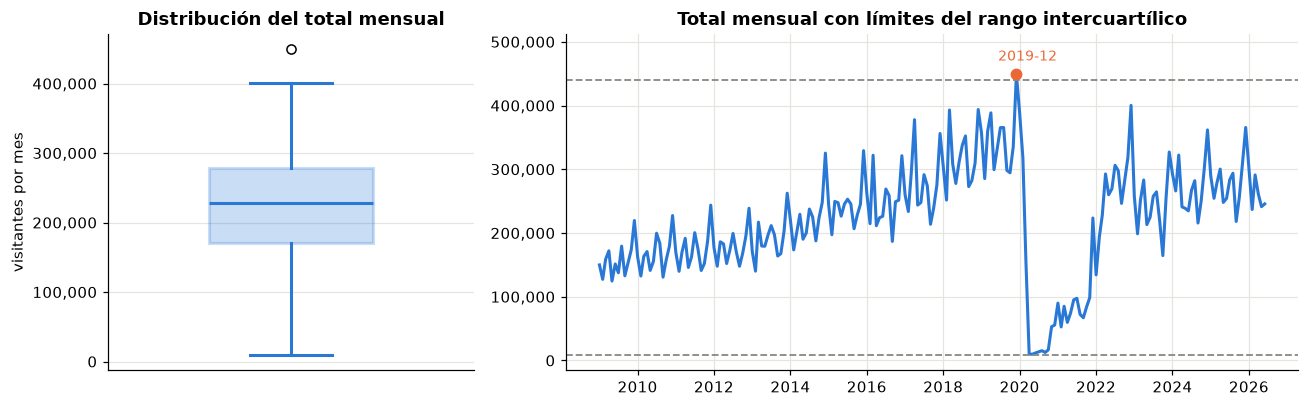

In [10]:
fig, ejes = plt.subplots(1, 2, figsize=(12, 3.8), gridspec_kw={"width_ratios": [1, 2]})

caja = ejes[0].boxplot(serie_mensual, vert=True, widths=0.45, patch_artist=True)
caja["boxes"][0].set(facecolor=AZUL, alpha=0.25, edgecolor=AZUL, linewidth=2)
for pieza in ["whiskers", "caps", "medians"]:
    for linea in caja[pieza]:
        linea.set(color=AZUL, linewidth=2)
ejes[0].set_title("Distribución del total mensual")
ejes[0].set_xticks([])
ejes[0].set_ylabel("visitantes por mes")
miles(ejes[0])

ejes[1].plot(serie_mensual.index, serie_mensual.values, color=AZUL, linewidth=2)
ejes[1].axhline(limite_alto, color=GRIS, linewidth=1.2, linestyle="--")
ejes[1].axhline(limite_bajo, color=GRIS, linewidth=1.2, linestyle="--")
ejes[1].scatter(atipicos.index, atipicos.values, color=NARANJA, s=45, zorder=5)
for fecha, valor in atipicos.items():
    ejes[1].annotate(f"{fecha:%Y-%m}", (fecha, valor), textcoords="offset points",
                     xytext=(-12, 9), fontsize=9, color=NARANJA)
ejes[1].set_title("Total mensual con límites del rango intercuartílico")
ejes[1].set_ylim(-15_000, serie_mensual.max() * 1.14)
miles(ejes[1])

guardar("02_atipicos")
plt.show()

El único mes que el criterio del rango intercuartílico marca como atípico es diciembre de 2019, con
449,114 visitantes, que fue el pico histórico de la serie antes de la pandemia. Lo interesante es lo que
el criterio no marca. Los meses del confinamiento, con mínimos de 9,779 visitantes en mayo de 2020,
quedan apenas por dentro del límite inferior y no se señalan como atípicos.

Eso no significa que sean normales, significa que el colapso duró lo suficiente como para desplazar los
propios cuartiles de la distribución. Cuando un evento extremo abarca alrededor de veinte meses de una
serie de doscientos diez, deja de comportarse como un dato aislado y pasa a formar parte de la
distribución. Es un buen recordatorio de que las reglas automáticas de detección de atípicos suponen un
proceso estable, y esta serie no lo es. Por eso tratamos la pandemia como un quiebre estructural en la
sección 5 y no como un conjunto de puntos a depurar. Ninguno de estos valores debe eliminarse, son
observaciones legítimas del fenómeno que estamos modelando.

## 3. Comportamiento temporal del número de viajeros

Esta es la parte central del análisis exploratorio, porque es la que define qué tan modelable es la
serie que vamos a construir después.

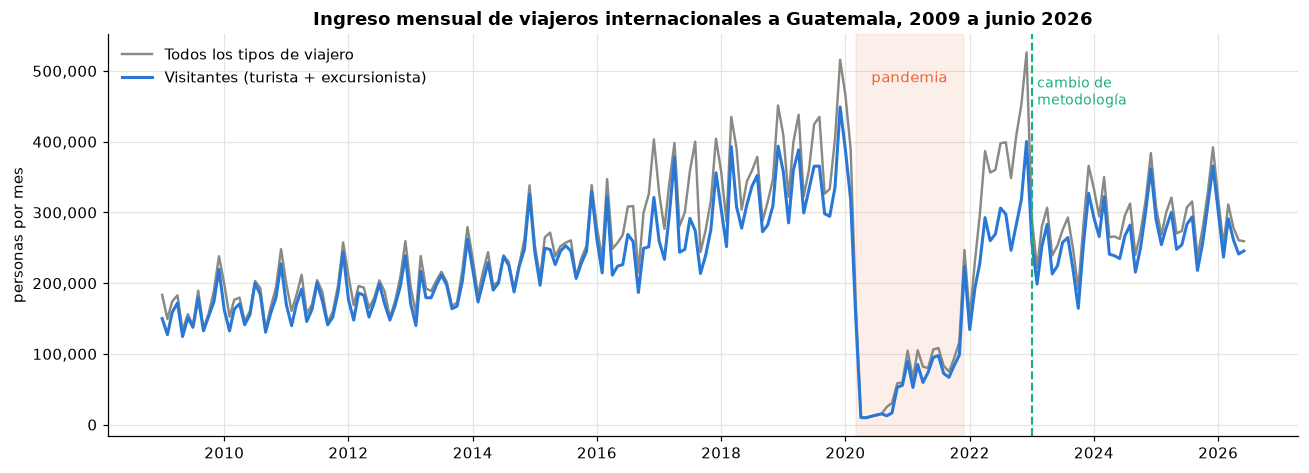

In [11]:
serie_total = df.groupby("fecha")["viajeros"].sum()

fig, eje = plt.subplots(figsize=(12, 4.4))
eje.plot(serie_total.index, serie_total.values, color=GRIS, linewidth=1.6,
         label="Todos los tipos de viajero")
eje.plot(serie_mensual.index, serie_mensual.values, color=AZUL, linewidth=2,
         label="Visitantes (turista + excursionista)")
eje.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-12-01"), color=NARANJA, alpha=0.10)
eje.annotate("pandemia", (pd.Timestamp("2020-06-01"), serie_total.max() * 0.92),
             color=NARANJA, fontsize=10)
eje.axvline(pd.Timestamp("2023-01-01"), color=AQUA, linewidth=1.4, linestyle="--")
eje.annotate("cambio de\nmetodología", (pd.Timestamp("2023-02-01"), serie_total.max() * 0.86),
             color=AQUA, fontsize=9)
eje.set_title("Ingreso mensual de viajeros internacionales a Guatemala, 2009 a junio 2026")
eje.set_ylabel("personas por mes")
eje.legend(loc="upper left")
miles(eje)

guardar("03_serie_mensual")
plt.show()

In [12]:
anual = pd.DataFrame({
    "total": df.groupby("anio")["viajeros"].sum(),
    "visitantes": visitantes.groupby("anio")["viajeros"].sum(),
})
anual["indice_vs_2019"] = (anual["visitantes"] / anual.loc[2019, "visitantes"] * 100).round(1)
anual["var_anual_%"] = (anual["visitantes"].pct_change() * 100).round(1)
anual.round(0)

,total,visitantes,indice_vs_2019,var_anual_%
anio,,,,
2009,2028776.0,1880183.0,46.0,NaN
2010,2152899.0,2004784.0,48.0,7.0
2011,2231456.0,2079715.0,50.0,4.0
2012,2299816.0,2139541.0,52.0,3.0
2013,2432169.0,2289703.0,55.0,7.0
2014,2762602.0,2660177.0,64.0,16.0
2015,3041643.0,2917886.0,71.0,10.0
2016,3496217.0,2997027.0,72.0,3.0
2017,3921460.0,3307651.0,80.0,10.0


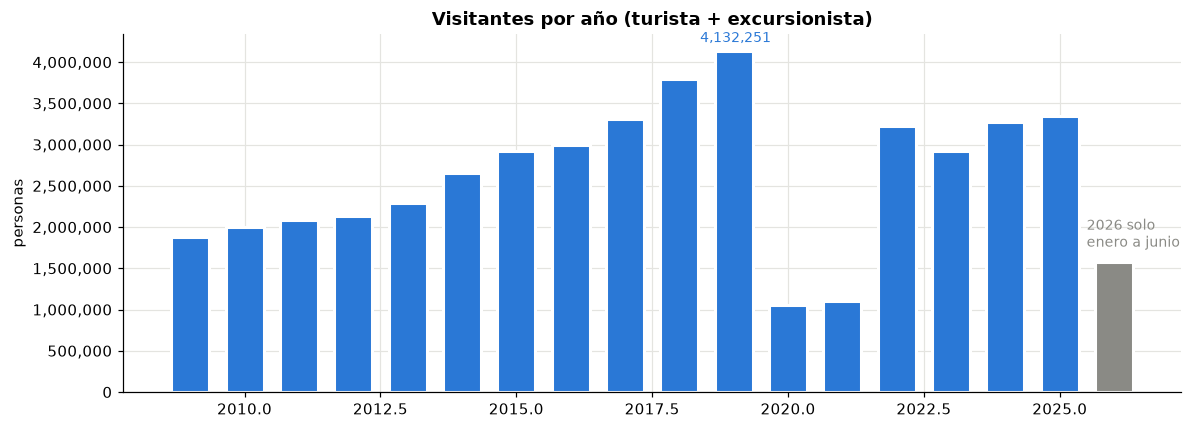

In [13]:
fig, eje = plt.subplots(figsize=(11, 4))
colores = [GRIS if a == 2026 else AZUL for a in anual.index]
barras = eje.bar(anual.index, anual["visitantes"], color=colores, width=0.7)
for barra, anio in zip(barras, anual.index):
    barra.set_linewidth(2)
    barra.set_edgecolor("white")
eje.annotate("2026 solo\nenero a junio", (2026, anual.loc[2026, "visitantes"]),
             textcoords="offset points", xytext=(-18, 10), fontsize=9, color=GRIS)
eje.annotate(f"{anual.loc[2019, 'visitantes']:,.0f}", (2019, anual.loc[2019, "visitantes"]),
             textcoords="offset points", xytext=(-22, 6), fontsize=9, color=AZUL)
eje.set_title("Visitantes por año (turista + excursionista)")
eje.set_ylabel("personas")
miles(eje)

guardar("03_totales_anuales")
plt.show()

La serie tiene tres regímenes claramente distintos y ninguno se parece al anterior.

El primero va de 2009 a 2019 y es un crecimiento sostenido y bastante regular. Los visitantes pasan de
1.88 millones a 4.13 millones, lo que equivale a más que duplicarse en once años, con una tasa que se
acelera entre 2014 y 2019. Sobre este tramo la serie se ve razonablemente bien comportada, con tendencia
positiva y una estacionalidad marcada que analizamos en la siguiente sección.

El segundo es la pandemia. La caída es abrupta y no gradual, entre febrero y mayo de 2020 la serie pasa
de 317,918 a 9,779 visitantes mensuales, una contracción de 97 por ciento en tres meses. El piso se
mantiene casi dos años, 2020 y 2021 cierran en 25.6 y 26.6 por ciento del nivel de 2019 respectivamente.

El tercero es la recuperación desde 2022, que se estabiliza en un nivel sistemáticamente por debajo del
de 2019. En 2025, con seis años transcurridos, los visitantes llegan a 3.35 millones, un 81 por ciento
del nivel prepandemia. Aquí hay que tener cuidado al interpretar, porque parte de esa brecha es real y
parte es metodológica. La línea vertical de 2023 marca el cambio de fuente que describen las notas del
conjunto, y como mostramos en la sección 6, ese cambio elimina una categoría que antes aportaba alrededor
de un tercio del volumen. La conclusión honesta es que la serie no ha vuelto a su nivel de 2019, pero la
magnitud exacta de la brecha no es medible con estos datos sin ajustar por el cambio de definición.

Para efectos del modelado, lo relevante es que una serie con dos quiebres estructurales de esta magnitud
no va a ser estacionaria en media ni en varianza, y que ningún modelo ARIMA estándar va a capturar la
caída de 2020 porque no es un shock que el proceso genere por sí mismo.

## 4. Estacionalidad

Para aislar el patrón estacional del efecto de la pandemia, calculamos el índice usando solo el tramo
prepandemia, de 2009 a 2019, donde el proceso es estable.

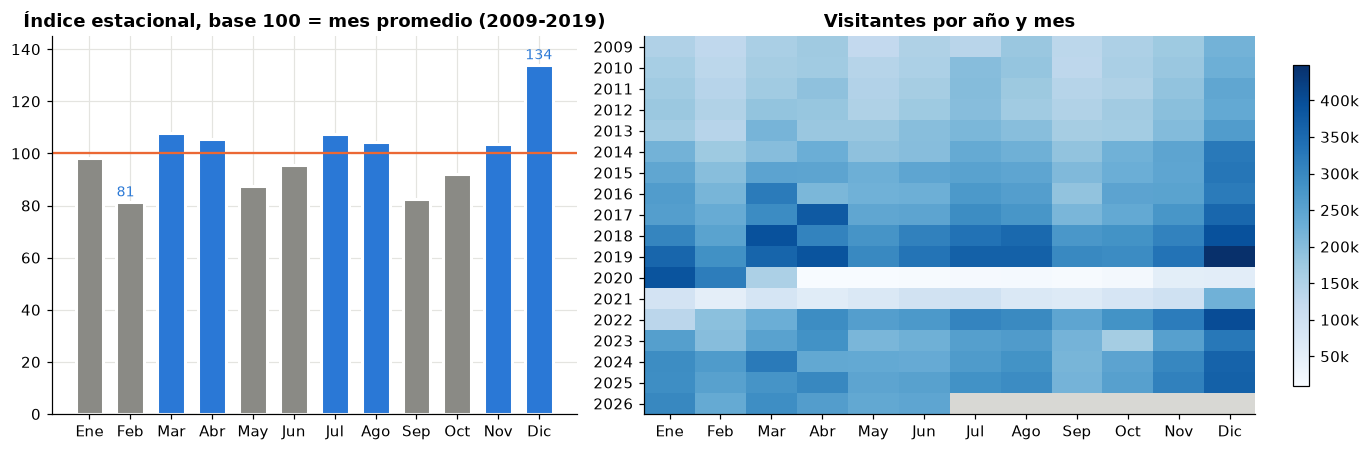

Ene     98.4
Feb     81.2
Mar    107.8
Abr    105.7
May     87.6
Jun     95.5
Jul    107.4
Ago    104.4
Sep     82.7
Oct     92.0
Nov    103.5
Dic    133.8


In [14]:
pre = visitantes[visitantes["anio"] <= 2019]
por_mes = pre.groupby(pre["fecha"].dt.month)["viajeros"].sum() / pre["anio"].nunique()
indice = (por_mes / por_mes.mean() * 100).round(1)
indice.index = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]

fig, ejes = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"width_ratios": [1.1, 1.6]})

colores = [AZUL if v >= 100 else GRIS for v in indice]
ejes[0].bar(indice.index, indice.values, color=colores, width=0.68, edgecolor="white", linewidth=2)
ejes[0].axhline(100, color=NARANJA, linewidth=1.5)
for etiqueta in ["Dic", "Feb"]:
    ejes[0].annotate(f"{indice[etiqueta]:.0f}", (etiqueta, indice[etiqueta]),
                     textcoords="offset points", xytext=(-9, 4), fontsize=9, color=AZUL)
ejes[0].set_title("Índice estacional, base 100 = mes promedio (2009-2019)")
ejes[0].set_ylim(0, 145)

pivote = (visitantes.pivot_table(index="anio", columns=visitantes["fecha"].dt.month,
                                values="viajeros", aggfunc="sum")
          .reindex(columns=range(1, 13)))
# Los meses inexistentes (julio a diciembre de 2026) se pintan en gris para que no
# se confundan con los meses de valor casi cero de la pandemia.
mapa = plt.get_cmap("Blues").copy()
mapa.set_bad("#d8d8d4")
imagen = ejes[1].imshow(np.ma.masked_invalid(pivote.values), aspect="auto",
                        cmap=mapa, interpolation="nearest")
ejes[1].set_xticks(range(12), indice.index)
ejes[1].set_yticks(range(len(pivote)), pivote.index)
ejes[1].set_title("Visitantes por año y mes")
ejes[1].grid(False)
fig.colorbar(imagen, ax=ejes[1], shrink=0.85, format=lambda v, _: f"{v/1000:,.0f}k")

guardar("04_estacionalidad")
plt.show()
print(indice.to_string())

El patrón estacional es fuerte y muy estable. Diciembre es el mes más alto del año con un índice de
133.8, es decir un 34 por ciento por encima del mes promedio, y responde a la temporada de fin de año.
Le siguen marzo y julio, con 107.8 y 107.4, que corresponden a Semana Santa y a las vacaciones de medio
año. En el otro extremo, febrero y septiembre son los meses más bajos con 81.2 y 82.7.

La amplitud entre el mes más alto y el más bajo es de más de cincuenta puntos sobre una base de cien, lo
que confirma que la estacionalidad es un componente dominante de esta serie y no un detalle menor.
Cualquier modelo que ignore el componente estacional va a fallar sistemáticamente, así que los modelos
que probemos después tendrán que ser estacionales, sea un SARIMA con periodo doce o alternativas como
Holt-Winters que modelan la estacionalidad de forma explícita.

El mapa de calor muestra además que el patrón se mantiene año con año, con la misma banda oscura en
diciembre y la misma banda clara en febrero y septiembre. Las dos filas casi vacías de 2020 y 2021 son
la pandemia, y ahí el patrón estacional simplemente desaparece, lo cual es otra señal de que ese tramo
se comporta como un régimen aparte.

Un detalle que conviene retener para la fase de modelado, la amplitud estacional crece junto con el
nivel de la serie. Los picos de diciembre de los años recientes son mucho más grandes en términos
absolutos que los de 2009. Eso apunta a una estacionalidad multiplicativa más que aditiva, y sugiere que
una transformación logarítmica va a ayudar a estabilizar la varianza.

## 5. Comportamiento durante y después de la pandemia

In [15]:
tramos = {
    "Prepandemia 2017-2019": ("2017-01", "2019-12"),
    "Colapso 2020-2021": ("2020-03", "2021-12"),
    "Recuperación 2022-2026": ("2022-01", "2026-06"),
}
filas = []
for nombre, (inicio, fin) in tramos.items():
    tramo = serie_mensual.loc[inicio:fin]
    filas.append({
        "tramo": nombre, "meses": len(tramo),
        "promedio_mensual": round(tramo.mean()),
        "minimo": round(tramo.min()), "maximo": round(tramo.max()),
        "desv_est": round(tramo.std()),
        "coef_variacion": round(tramo.std() / tramo.mean(), 2),
    })
pd.DataFrame(filas).set_index("tramo")

,meses,promedio_mensual,minimo,maximo,desv_est,coef_variacion
tramo,,,,,,
Prepandemia 2017-2019,36,312046,213697,449114,54069,0.17
Colapso 2020-2021,22,66027,9779,223569,52288,0.79
Recuperación 2022-2026,54,265750,134303,400266,46834,0.18


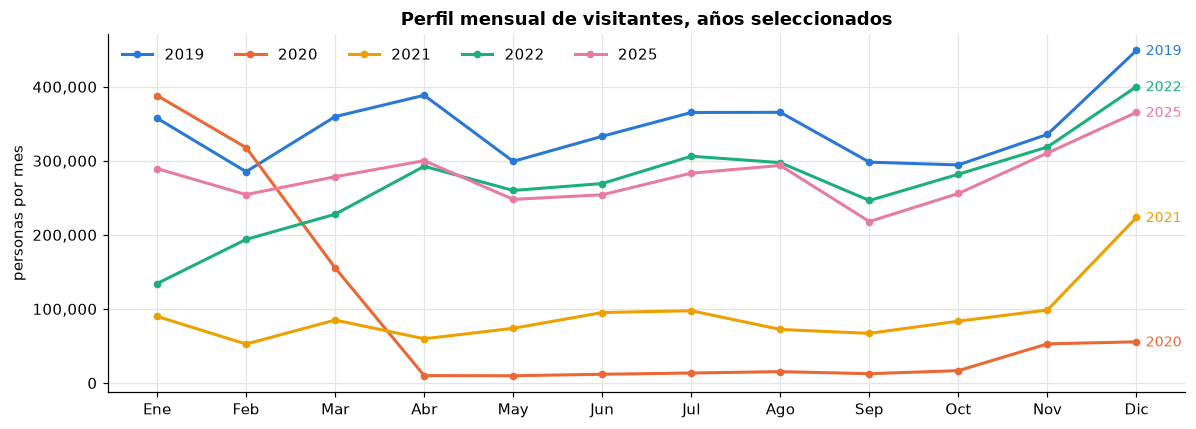

In [16]:
fig, eje = plt.subplots(figsize=(11, 4))
comparar = {2019: AZUL, 2020: NARANJA, 2021: AMARILLO, 2022: AQUA, 2025: MAGENTA}
for anio, color in comparar.items():
    tramo = serie_mensual[serie_mensual.index.year == anio]
    eje.plot(range(1, len(tramo) + 1), tramo.values, color=color, linewidth=2,
             marker="o", markersize=4, label=str(anio))
    eje.annotate(str(anio), (len(tramo), tramo.iloc[-1]), textcoords="offset points",
                 xytext=(6, -3), fontsize=9, color=color)
eje.set_xticks(range(1, 13), indice.index)
eje.set_title("Perfil mensual de visitantes, años seleccionados")
eje.set_ylabel("personas por mes")
eje.legend(loc="upper left", ncol=5)
miles(eje)

guardar("05_pandemia")
plt.show()

Los tres tramos se distinguen no solo por su nivel sino por su variabilidad. El tramo prepandemia
promedia 312,046 visitantes mensuales con un coeficiente de variación de 0.17, es decir es un proceso
bastante regular. El colapso promedia 66,027 al mes, apenas un 21 por ciento de ese nivel, y su
coeficiente de variación se dispara a 0.79 porque dentro del tramo conviven el fondo absoluto de mayo de
2020, con 9,779 visitantes, y el arranque de la reapertura de finales de 2021, con 223,569. La
recuperación promedia 265,750 mensuales con un coeficiente de 0.18, o sea recuperó la regularidad pero
no el nivel.

El gráfico de perfiles mensuales muestra el mecanismo con claridad. La curva de 2019 y la de 2025 tienen
la misma forma, suben hacia diciembre y caen en febrero y septiembre, pero la de 2025 corre por debajo
en prácticamente todo el año. La de 2020 arranca pegada a la de 2019 durante enero y febrero, se
desploma en marzo y se queda plana el resto del año, sin ningún rastro del pico de diciembre. La de 2021
es una línea baja y casi horizontal, con una recuperación que apenas se insinúa al final.

Lo que nos parece más relevante de esta sección es que la estacionalidad desaparece por completo durante
2020 y 2021 y reaparece intacta en 2022. Eso quiere decir que el shock afectó el nivel de la serie, no
su estructura estacional. Para el modelado esto es una buena noticia y un problema a la vez. Es buena
noticia porque el componente estacional estimado sobre los años normales sigue siendo válido. Es un
problema porque incluir 2020 y 2021 en el entrenamiento va a distorsionar la estimación de la tendencia
y a inflar la varianza de los residuos.

## 6. Países con mayor cantidad de viajeros

In [17]:
top_paises = visitantes.groupby("pais")["viajeros"].sum().sort_values(ascending=False)
tabla = top_paises.head(12).to_frame("visitantes")
tabla["participacion_%"] = (tabla["visitantes"] / top_paises.sum() * 100).round(1)
tabla["acumulado_%"] = tabla["participacion_%"].cumsum().round(1)
tabla.round(0)

,visitantes,participacion_%,acumulado_%
pais,,,
El Salvador,14079136.0,30.0,30.0
Guatemala,13870391.0,30.0,60.0
Estados Unidos de América,6965680.0,15.0,75.0
Honduras,2520974.0,5.0,80.0
México,1678423.0,4.0,84.0
Belice,916101.0,2.0,86.0
Costa Rica,860241.0,2.0,88.0
Nicaragua,811145.0,2.0,89.0
Colombia,549495.0,1.0,90.0


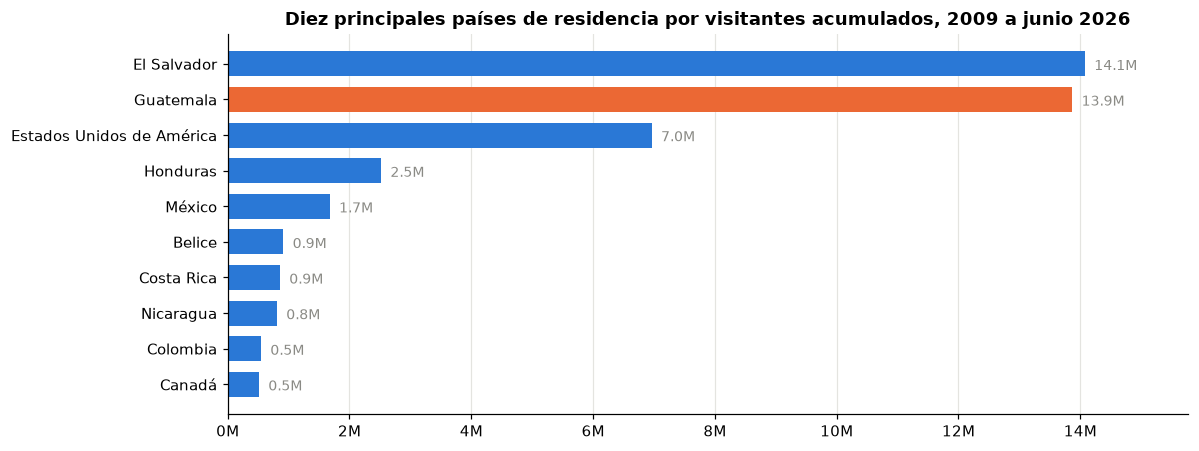

In [18]:
fig, eje = plt.subplots(figsize=(11, 4.2))
top10 = top_paises.head(10).sort_values()
colores = [NARANJA if p == "Guatemala" else AZUL for p in top10.index]
barras = eje.barh(top10.index, top10.values, color=colores, height=0.7)
for barra, valor in zip(barras, top10.values):
    eje.annotate(f"{valor/1e6:,.1f}M", (valor, barra.get_y() + barra.get_height() / 2),
                 textcoords="offset points", xytext=(6, -4), fontsize=9, color=GRIS)
eje.set_title("Diez principales países de residencia por visitantes acumulados, 2009 a junio 2026")
eje.set_xlim(0, top10.max() * 1.12)
eje.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1e6:,.0f}M"))
eje.grid(axis="y", visible=False)

guardar("06_paises")
plt.show()

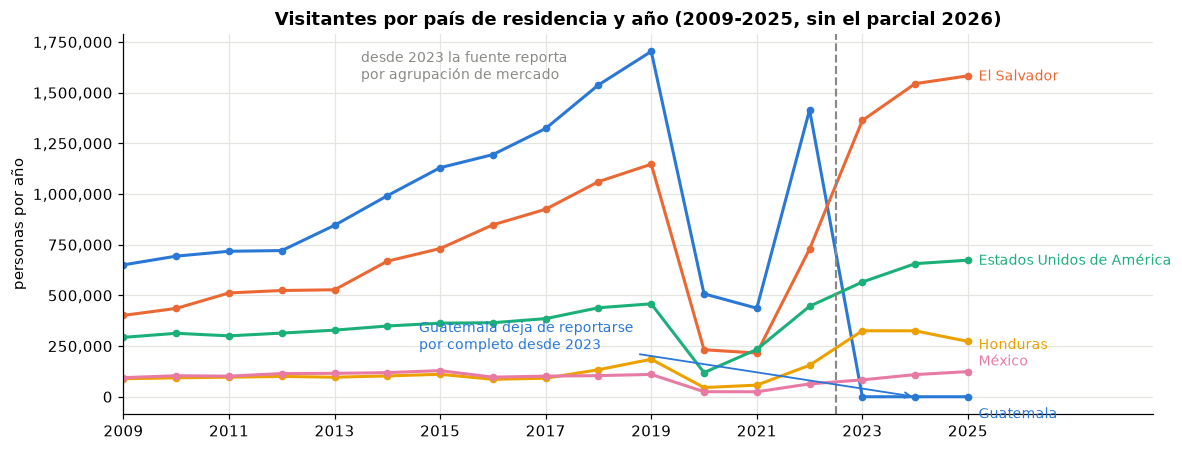

Países distintos reportados por año:
anio
2009    200
2010    200
2011    204
2012    201
2013    198
2014    203
2015    206
2016    206
2017    207
2018    199
2019    203
2020    183
2021    180
2022    104
2023     26
2024     26
2025     26
2026     26


In [19]:
seguimiento = ["Guatemala", "El Salvador", "Estados Unidos de América", "Honduras", "México"]
# Excluimos 2026 porque solo cubre enero a junio y en un corte anual se leería como una caída.
por_anio = (visitantes[(visitantes["pais"].isin(seguimiento)) & (visitantes["anio"] <= 2025)]
            .pivot_table(index="anio", columns="pais", values="viajeros", aggfunc="sum")
            .reindex(columns=seguimiento).fillna(0))

# Separación vertical de las etiquetas para que no se encimen en el borde derecho.
desplazamiento = {"Guatemala": -11, "México": 7, "Honduras": -2,
                  "El Salvador": 0, "Estados Unidos de América": 0}

fig, eje = plt.subplots(figsize=(11, 4.2))
for nombre, color in zip(seguimiento, PALETA):
    eje.plot(por_anio.index, por_anio[nombre], color=color, linewidth=2, marker="o", markersize=4)
    eje.annotate(nombre, (por_anio.index[-1], por_anio[nombre].iloc[-1]),
                 textcoords="offset points", xytext=(7, desplazamiento[nombre] - 3),
                 fontsize=9, color=color)
eje.axvline(2022.5, color=GRIS, linewidth=1.4, linestyle="--")
eje.annotate("desde 2023 la fuente reporta\npor agrupación de mercado",
             (2013.5, por_anio.max().max() * 0.92), fontsize=9, color=GRIS)
eje.annotate("Guatemala deja de reportarse\npor completo desde 2023",
             xy=(2024, 0), xytext=(2014.6, 235_000), fontsize=9, color=AZUL,
             arrowprops=dict(arrowstyle="->", color=AZUL, linewidth=1.2))
eje.set_title("Visitantes por país de residencia y año (2009-2025, sin el parcial 2026)")
eje.set_xlim(2009, 2028.5)
eje.set_xticks(range(2009, 2026, 2))
eje.set_ylabel("personas por año")
miles(eje)

guardar("06_paises_evolucion")
plt.show()
print("Países distintos reportados por año:")
print(visitantes.groupby("anio")["pais"].nunique().to_string())

El ranking acumulado lo encabezan El Salvador con 14.08 millones de visitantes, Guatemala con 13.87
millones y Estados Unidos con 6.97 millones. Entre los tres concentran el 74.7 por ciento de todos los
visitantes del período, y si se agregan Honduras y México se llega al 83.7 por ciento. La concentración
es altísima, lo que refleja que el turismo receptivo guatemalteco es sobre todo un fenómeno regional
centroamericano complementado por el mercado estadounidense.

Ahora, el segundo lugar de ese ranking exige una advertencia importante, y es el hallazgo que consideramos
más consecuente de esta sección. Guatemala aparece como país de residencia porque la fuente registra
también a los residentes guatemaltecos que regresan al país, que no son turismo receptivo en sentido
estricto. Pero además, y esto es lo crítico, la categoría desaparece por completo a partir de 2023. En
2022 aportó 1.42 millones de visitantes y en 2023 aporta cero, y lo mismo en 2024, 2025 y el tramo de
2026. No es una caída, es una exclusión metodológica, la nueva fuente depurada simplemente dejó de
contar a los residentes del propio país.

Esto explica buena parte de la brecha que observamos en la sección 3. La serie total no ha vuelto al nivel
de 2019 en parte porque desde 2023 dejó de incluir un componente que antes valía alrededor de un tercio
del volumen. Los mercados extranjeros, en cambio, sí superaron su nivel prepandemia. El Salvador pasó
de 1.15 millones en 2019 a 1.58 millones en 2025, y Estados Unidos de 458 mil a 674 mil. Leído así, el
turismo receptivo genuino está mejor que antes de la pandemia, y la caída aparente del total es un
artefacto de la definición.

El conteo de países distintos por año confirma el cambio de granularidad que anticipaban las notas. De
2009 a 2021 la fuente reporta alrededor de doscientos países individuales, en 2022 baja a 109 y desde
2023 se estabiliza en 26 agrupaciones de mercado. Esto tiene una implicación práctica directa para el
siguiente paso del laboratorio, y la retomamos en la sección 11.

## 7. Regiones con mayor cantidad de viajeros

In [20]:
regiones = visitantes.groupby("region_dos")["viajeros"].sum().sort_values(ascending=False)
tabla_regiones = regiones.to_frame("visitantes")
tabla_regiones["participacion_%"] = (tabla_regiones["visitantes"] / regiones.sum() * 100).round(2)
tabla_regiones.round(0)

,visitantes,participacion_%
region_dos,,
América Del Centro,33283932.0,71.0
América Del Norte,9160810.0,20.0
Europa,2149271.0,5.0
América Del Sur y el Caribe,1413590.0,3.0
Asia,410334.0,1.0
Oceanía,135505.0,0.0
Oriente Medio,133735.0,0.0
Otros Paises Del Mundo,23914.0,0.0
Sin clasificar,821.0,0.0


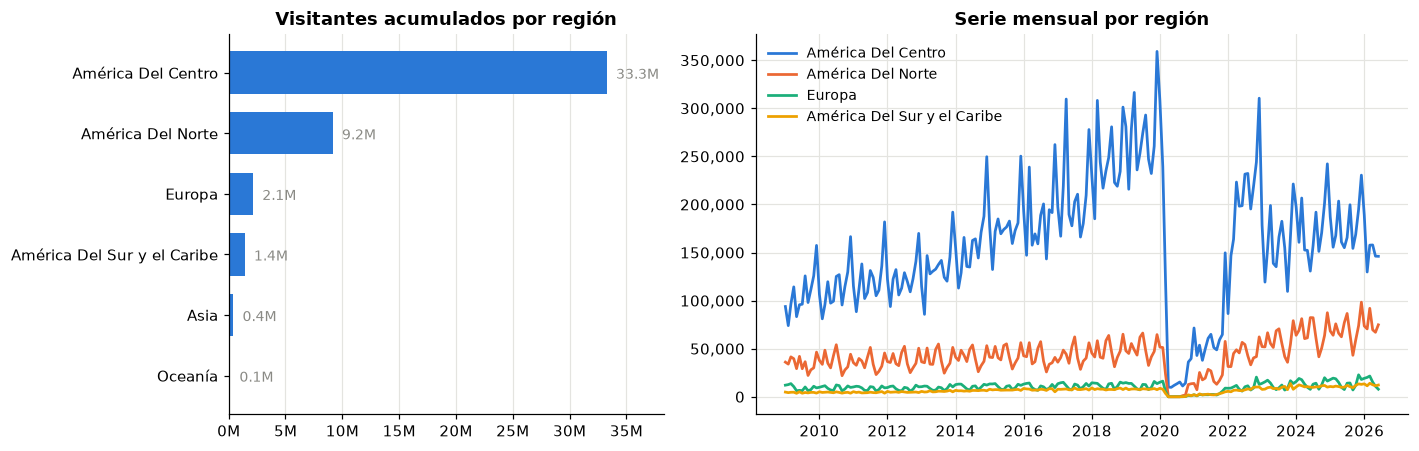

In [21]:
principales = regiones.head(4).index.tolist()
serie_region = (visitantes[visitantes["region_dos"].isin(principales)]
                .pivot_table(index="fecha", columns="region_dos", values="viajeros", aggfunc="sum")
                .reindex(columns=principales).fillna(0))

fig, ejes = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"width_ratios": [1, 1.5]})

orden = regiones.head(6).sort_values()
barras = ejes[0].barh(orden.index, orden.values, color=AZUL, height=0.7)
for barra, valor in zip(barras, orden.values):
    ejes[0].annotate(f"{valor/1e6:,.1f}M", (valor, barra.get_y() + barra.get_height() / 2),
                     textcoords="offset points", xytext=(6, -4), fontsize=9, color=GRIS)
ejes[0].set_title("Visitantes acumulados por región")
ejes[0].set_xlim(0, orden.max() * 1.15)
ejes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1e6:,.0f}M"))
ejes[0].grid(axis="y", visible=False)

for nombre, color in zip(principales, PALETA):
    ejes[1].plot(serie_region.index, serie_region[nombre], color=color, linewidth=1.8, label=nombre)
ejes[1].set_title("Serie mensual por región")
ejes[1].legend(loc="upper left", fontsize=9)
miles(ejes[1])

guardar("07_regiones")
plt.show()

La distribución regional es todavía más concentrada que la de países. América del Centro aporta 33.28
millones de visitantes, el 71.3 por ciento del total, seguida de América del Norte con 9.16 millones y
19.6 por ciento, y Europa con 2.15 millones y 4.6 por ciento. Las tres primeras regiones suman el 95.5
por ciento, y las cinco restantes juntas, Asia, Oceanía, Oriente Medio y el resto del mundo, no llegan
al uno por ciento cada una.

La serie mensual por región muestra que las tres principales comparten la misma forma general, crecen
hasta 2019, colapsan en 2020 y se recuperan desde 2022, pero con amplitudes muy distintas. América del
Centro es la que impone el perfil del total, dado su peso, y también la más volátil en términos
absolutos. Europa se mueve en un rango tan pequeño en comparación que en el mismo eje casi se aplana, lo
cual por sí solo dice algo útil, la diversificación de mercados de Guatemala es baja y depende
fuertemente de sus vecinos inmediatos.

Vale la pena notar que la categoría Sin clasificar, producto de la limpieza, aporta 821 visitantes en
todo el período, un 0.002 por ciento del total. Es completamente irrelevante para cualquier análisis
agregado, lo cual confirma que la decisión de reetiquetar en vez de descartar no distorsiona nada.

## 8. Vías de ingreso

In [22]:
vias = visitantes.groupby("via")["viajeros"].sum().sort_values(ascending=False)
resumen_vias = vias.to_frame("visitantes")
resumen_vias["participacion_%"] = (resumen_vias["visitantes"] / vias.sum() * 100).round(2)

print(resumen_vias.round(0).to_string())
print()
print("Participación anual de cada vía (%), visitantes:")
share = visitantes.pivot_table(index="anio", columns="via", values="viajeros", aggfunc="sum").fillna(0)
print((share.div(share.sum(axis=1), axis=0) * 100).round(1).to_string())

           visitantes  participacion_%
via                                   
Terrestre  27592253.0             59.0
Aérea      19019419.0             41.0
Marítima     100241.0              0.0

Participación anual de cada vía (%), visitantes:
via   Aérea  Marítima  Terrestre
anio                            
2009   49.7       0.7       49.6
2010   48.6       0.6       50.8
2011   46.0       0.6       53.4
2012   45.4       0.6       54.0
2013   43.5       0.6       55.9
2014   41.1       0.5       58.4
2015   40.0       0.4       59.6
2016   41.9       0.4       57.8
2017   39.7       0.0       60.3
2018   37.3       0.0       62.7
2019   35.9       0.0       64.1
2020   38.1       0.0       61.9
2021   64.0       0.0       36.0
2022   43.1       0.0       56.9
2023   33.8       0.0       66.2
2024   34.9       0.0       65.1
2025   35.5       0.0       64.5
2026   40.8       0.0       59.2


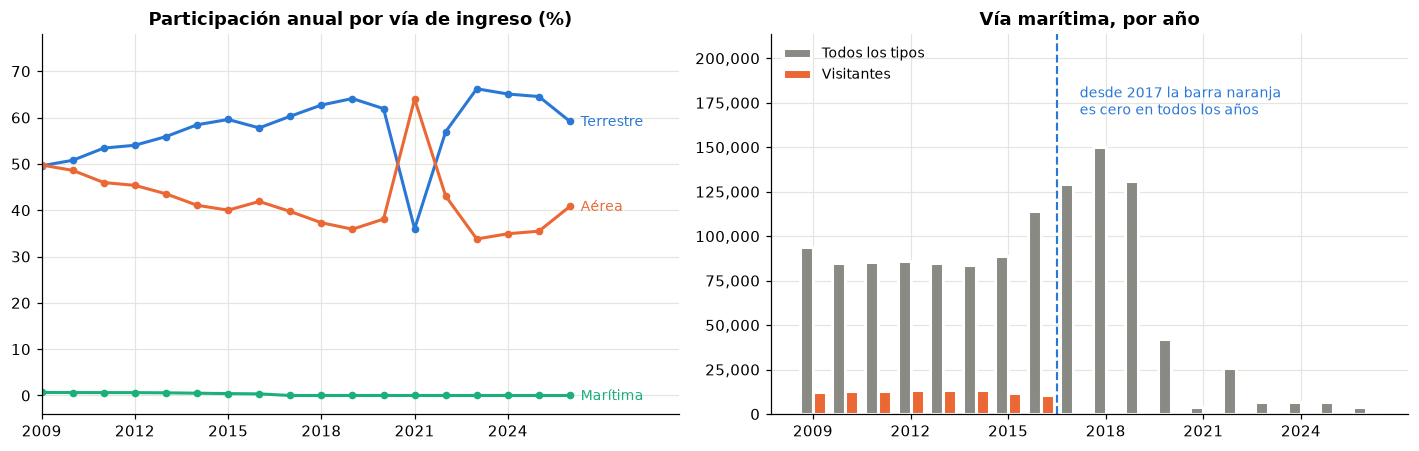

      visitantes  todos_los_tipos
anio                             
2009     12358.0          93704.0
2010     12675.0          85163.0
2011     12969.0          85319.0
2012     13282.0          86128.0
2013     13242.0          84932.0
2014     13256.0          83857.0
2015     11881.0          89076.0
2016     10578.0         114290.0
2017         0.0         129063.0
2018         0.0         150392.0
2019         0.0         130789.0
2020         0.0          41992.0
2021         0.0           3908.0
2022         0.0          26030.0
2023         0.0           6617.0
2024         0.0           6605.0
2025         0.0           6944.0
2026         0.0           3973.0


In [23]:
maritima = pd.DataFrame({
    "visitantes": visitantes[visitantes["via"] == "Marítima"].groupby("anio")["viajeros"].sum(),
    "todos_los_tipos": df[df["via"] == "Marítima"].groupby("anio")["viajeros"].sum(),
}).fillna(0)

fig, ejes = plt.subplots(1, 2, figsize=(13, 4.2))

porcentaje = share.div(share.sum(axis=1), axis=0) * 100
for nombre, color in zip(["Terrestre", "Aérea", "Marítima"], PALETA):
    ejes[0].plot(porcentaje.index, porcentaje[nombre], color=color, linewidth=2, marker="o", markersize=4)
    ejes[0].annotate(nombre, (porcentaje.index[-1], porcentaje[nombre].iloc[-1]),
                     textcoords="offset points", xytext=(7, -3), fontsize=9, color=color)
ejes[0].set_title("Participación anual por vía de ingreso (%)")
ejes[0].set_ylim(-4, 78)
ejes[0].set_xlim(2009, 2029.5)
ejes[0].set_xticks(range(2009, 2027, 3))

ancho = 0.4
ejes[1].bar(maritima.index - ancho / 2, maritima["todos_los_tipos"], width=ancho,
            color=GRIS, edgecolor="white", linewidth=2, label="Todos los tipos")
ejes[1].bar(maritima.index + ancho / 2, maritima["visitantes"], width=ancho,
            color=NARANJA, edgecolor="white", linewidth=2, label="Visitantes")
ejes[1].axvline(2016.5, color=AZUL, linewidth=1.4, linestyle="--")
ejes[1].set_ylim(0, maritima["todos_los_tipos"].max() * 1.42)
ejes[1].annotate("desde 2017 la barra naranja\nes cero en todos los años",
                 (2017.2, maritima["todos_los_tipos"].max() * 1.12), fontsize=9, color=AZUL)
ejes[1].set_title("Vía marítima, por año")
ejes[1].legend(loc="upper left", fontsize=9)
ejes[1].set_xticks(range(2009, 2027, 3))
miles(ejes[1])

guardar("08_vias")
plt.show()
print(maritima.round(0).to_string())

La vía terrestre concentra el 59.1 por ciento de los visitantes y la aérea el 40.7, mientras que la
marítima apenas alcanza el 0.2 por ciento. Pero el dato agregado esconde un cambio de composición
interesante. En 2009 la vía aérea y la terrestre estaban prácticamente empatadas, con 49.7 y 49.6 por
ciento respectivamente, y para 2019 la terrestre había subido a 64.1 por ciento. El crecimiento del
turismo receptivo en la última década fue sobre todo crecimiento terrestre, es decir regional.

La única excepción a esa tendencia es 2021, donde la vía aérea salta a 64 por ciento. No es un cambio
estructural sino un efecto de la pandemia, las fronteras terrestres estuvieron cerradas o restringidas
más tiempo que el aeropuerto, así que el poco flujo que hubo fue predominantemente aéreo.

El hallazgo más importante de esta sección es el de la vía marítima, y va más allá de lo que advierten
las notas del conjunto. Las notas dicen que la vía marítima pierde detalle desde 2017. Lo que encontramos
al revisarlo es más severo, desde 2017 el número de visitantes por vía marítima es exactamente cero en
todos los meses. La vía marítima no desaparece de la base, sigue registrando entre seis mil y ciento
cincuenta mil personas al año, pero todas quedan clasificadas como Cruceristas, que no es ni turista ni
excursionista. Y como los cruceristas a su vez desaparecen de la base en 2023, la vía marítima queda
reducida a un residuo de alrededor de seis mil personas anuales.

Esto tiene una consecuencia directa sobre las opciones del laboratorio que discutimos en la sección 11.

## 9. Fronteras de ingreso

In [24]:
fronteras = visitantes.groupby("frontera")["viajeros"].sum().sort_values(ascending=False)
tabla_fronteras = fronteras.head(10).to_frame("visitantes")
tabla_fronteras["participacion_%"] = (tabla_fronteras["visitantes"] / fronteras.sum() * 100).round(1)
tabla_fronteras["acumulado_%"] = tabla_fronteras["participacion_%"].cumsum().round(1)
tabla_fronteras["via"] = [visitantes.loc[visitantes["frontera"] == f, "via"].mode()[0]
                          for f in tabla_fronteras.index]
tabla_fronteras.round(0)

,visitantes,participacion_%,acumulado_%,via
frontera,,,,
La Aurora,18989985.0,41.0,41.0,Aérea
Valle Nuevo,10143045.0,22.0,62.0,Terrestre
San Cristóbal,4183632.0,9.0,71.0,Terrestre
Pedro de Alvarado,3764229.0,8.0,80.0,Terrestre
La Ermita (Nueva Anguiatú),2587072.0,6.0,85.0,Terrestre
Melchor de Mencos,1782864.0,4.0,89.0,Terrestre
El Cinchado / El Corinto,1213485.0,3.0,91.0,Terrestre
Agua Caliente,922420.0,2.0,93.0,Terrestre
El Florido,910373.0,2.0,95.0,Terrestre


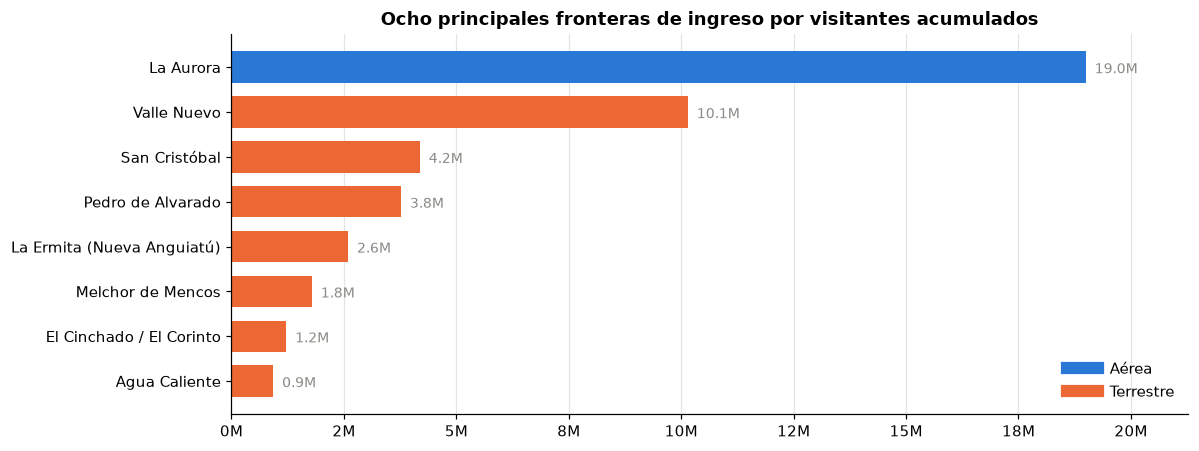

In [25]:
fig, eje = plt.subplots(figsize=(11, 4.2))
top8 = fronteras.head(8).sort_values()
color_via = {"Aérea": AZUL, "Terrestre": NARANJA, "Marítima": AQUA}
via_de = {f: visitantes.loc[visitantes["frontera"] == f, "via"].mode()[0] for f in top8.index}
barras = eje.barh(top8.index, top8.values, height=0.7,
                  color=[color_via[via_de[f]] for f in top8.index])
for barra, valor in zip(barras, top8.values):
    eje.annotate(f"{valor/1e6:,.1f}M", (valor, barra.get_y() + barra.get_height() / 2),
                 textcoords="offset points", xytext=(6, -4), fontsize=9, color=GRIS)
manijas = [plt.Line2D([], [], color=color_via[v], linewidth=8, label=v) for v in ["Aérea", "Terrestre"]]
eje.legend(handles=manijas, loc="lower right")
eje.set_title("Ocho principales fronteras de ingreso por visitantes acumulados")
eje.set_xlim(0, top8.max() * 1.12)
eje.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1e6:,.0f}M"))
eje.grid(axis="y", visible=False)

guardar("09_fronteras")
plt.show()

La Aurora, el aeropuerto internacional de la capital, es el punto de ingreso más importante con 18.99
millones de visitantes y el 40.7 por ciento del total, y por sí solo explica prácticamente toda la vía
aérea. Le siguen tres fronteras terrestres, Valle Nuevo con 10.14 millones y 21.7 por ciento, San
Cristóbal con 4.18 millones y 9 por ciento, y Pedro de Alvarado con 3.76 millones y 8.1 por ciento.

Las tres son fronteras con El Salvador, lo cual es coherente con que ese país encabece el ranking de
países de residencia. Entre las cuatro primeras se concentra el 79.4 por ciento de los visitantes, y las
veintidós fronteras registradas en la base tienen una cola muy larga de puntos con volúmenes marginales.

Un punto que conviene tener presente al construir series por frontera es que el patrón de cada una
refleja el país vecino al que conecta, no el comportamiento general del turismo. Valle Nuevo y Pedro de
Alvarado se mueven con el flujo salvadoreño, El Florido y Agua Caliente con el hondureño, Tecún Umán y
La Mesilla con el mexicano, y Melchor de Mencos con Belice. Eso las vuelve series interesantes de
analizar por separado, porque no son simplemente una partición proporcional del total.

## 10. Tipo de viajero

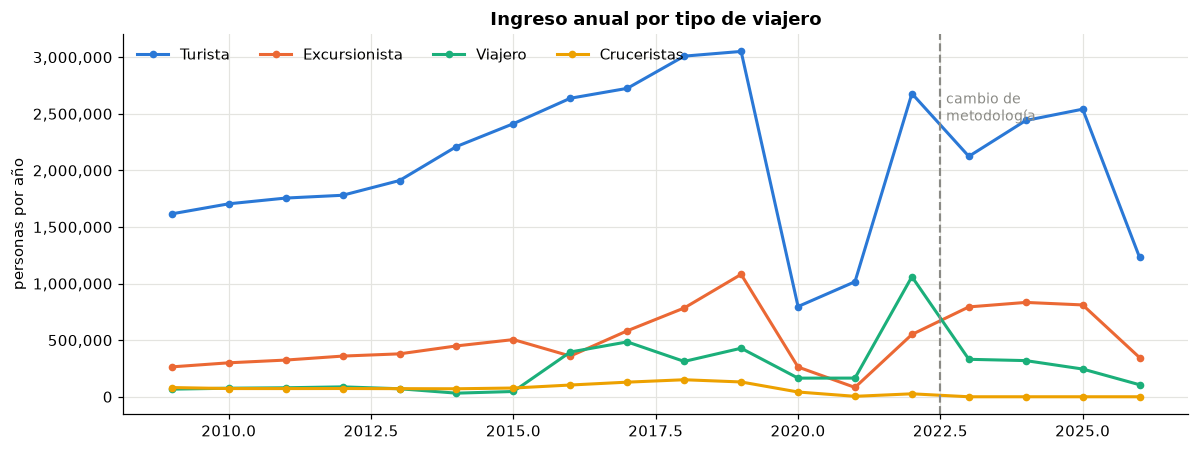

tipo_viajero,Turista,Excursionista,Viajero,Cruceristas
anio,,,,
2009,1616085.0,264098.0,67247.0,81346.0
2010,1704781.0,300003.0,75627.0,72488.0
2011,1755528.0,324187.0,79392.0,72350.0
2012,1780237.0,359304.0,87428.0,72846.0
2013,1910588.0,379115.0,70776.0,71690.0
2014,2210919.0,449258.0,31824.0,70601.0
2015,2412762.0,505124.0,46562.0,77195.0
2016,2637424.0,359603.0,395478.0,103712.0
2017,2724811.0,582840.0,484746.0,129063.0


In [26]:
tipos = df.pivot_table(index="anio", columns="tipo_viajero", values="viajeros", aggfunc="sum").fillna(0)
tipos_orden = ["Turista", "Excursionista", "Viajero", "Cruceristas"]
tipos = tipos.reindex(columns=tipos_orden)

fig, eje = plt.subplots(figsize=(11, 4.2))
for nombre, color in zip(tipos_orden, PALETA):
    eje.plot(tipos.index, tipos[nombre], color=color, linewidth=2, marker="o", markersize=4, label=nombre)
eje.axvline(2022.5, color=GRIS, linewidth=1.4, linestyle="--")
eje.annotate("cambio de\nmetodología", (2022.6, tipos.max().max() * 0.8), fontsize=9, color=GRIS)
eje.set_title("Ingreso anual por tipo de viajero")
eje.set_ylabel("personas por año")
eje.legend(loc="upper left", ncol=4)
miles(eje)

guardar("10_tipo_viajero")
plt.show()
tipos.round(0)

Los cuatro tipos de viajero se comportan de forma muy distinta y el gráfico deja ver por qué las notas
del conjunto insisten en usar solo turistas y excursionistas para comparar en todo el rango.

Los turistas son la categoría dominante y la más estable, van de 1.62 millones en 2009 a 3.05 millones
en 2019, caen a 797 mil en 2020 y se recuperan hasta 2.54 millones en 2025. Los excursionistas siguen
un perfil parecido pero con un crecimiento proporcionalmente mayor, se multiplican por cuatro entre 2009
y 2019, y son la categoría que más rápido se recuperó después de la pandemia.

La categoría Viajero es la problemática. Da un salto de 79 mil a 395 mil entre 2015 y 2016, se mantiene
alta hasta que en 2022 llega a 1.06 millones, y en 2023 cae a 331 mil. Esa caída no es un cambio en el
comportamiento de las personas, es la exclusión de los compradores fronterizos frecuentes que introdujo
la metodología depurada. Es exactamente el quiebre que advierten las notas y confirma que esta serie no
es comparable a lo largo de todo el período sin un ajuste explícito.

Los cruceristas terminan en 2022. Desde 2023 la fuente ya no los reporta porque los cruceros pasaron a
medirse por una fuente portuaria externa. Ochenta y siete de los doscientos diez meses de esa serie
están en cero, todos consecutivos al final, lo cual la descarta como candidata a modelar.

## 11. Viabilidad de las series candidatas

Esta sección no la pide explícitamente el enunciado, pero nos pareció necesaria. El punto 3 obliga a
elegir dos categorías de análisis, y varios de los valores que el enunciado nombra resultan no ser
modelables por lo que encontramos en las secciones anteriores. Dejamos la evidencia aquí para que la elección
sea informada y no una sorpresa a mitad del modelado.

In [27]:
rejilla = pd.date_range("2009-01-01", "2026-06-01", freq="MS")

def diagnosticar(sub, etiqueta):
    serie = sub.groupby("fecha")["viajeros"].sum().reindex(rejilla, fill_value=0)
    con_datos = serie[serie > 0]
    return {
        "serie": etiqueta,
        "acumulado": round(serie.sum()),
        "meses_en_cero": int((serie == 0).sum()),
        "ultimo_mes_con_datos": f"{con_datos.index.max():%Y-%m}" if len(con_datos) else "-",
        "coef_variacion": round(serie.std() / serie.mean(), 2),
    }

filas = [diagnosticar(visitantes, "TOTAL visitantes (serie obligatoria)")]
for columna, etiqueta in [("pais", "País"), ("region_dos", "Región"), ("frontera", "Frontera")]:
    top3 = visitantes.groupby(columna)["viajeros"].sum().nlargest(3).index
    filas += [diagnosticar(visitantes[visitantes[columna] == v], f"{etiqueta}: {v}") for v in top3]
for v in ["Aérea", "Terrestre", "Marítima"]:
    filas.append(diagnosticar(visitantes[visitantes["via"] == v], f"Vía: {v}"))
for v in ["Turista", "Excursionista", "Viajero", "Cruceristas"]:
    filas.append(diagnosticar(df[df["tipo_viajero"] == v], f"Tipo: {v}"))

diagnostico = pd.DataFrame(filas).set_index("serie")
diagnostico

,acumulado,meses_en_cero,ultimo_mes_con_datos,coef_variacion
serie,,,,
TOTAL visitantes (serie obligatoria),46711913,0,2026-06,0.38
País: El Salvador,14079136,5,2026-06,0.58
País: Guatemala,13870391,42,2022-12,0.72
País: Estados Unidos de América,6965680,5,2026-06,0.46
Región: América Del Centro,33283932,0,2026-06,0.42
Región: América Del Norte,9160810,5,2026-06,0.41
Región: Europa,2149271,5,2026-06,0.43
Frontera: La Aurora,18989985,0,2026-06,0.31
Frontera: Valle Nuevo,10143045,0,2026-06,0.49


La tabla resume lo que cada serie candidata puede sostener. Cuatro conclusiones salen de ahí.

Las series por región y por frontera son las más sanas. Las tres regiones principales, América del
Centro, América del Norte y Europa, y las tres fronteras principales, La Aurora, Valle Nuevo y San
Cristóbal, cubren los doscientos diez meses sin huecos y llegan hasta junio de 2026, con coeficientes de
variación entre 0.31 y 0.57 que son comparables al de la serie total.

Las vías de ingreso no funcionan como grupo. Aérea y terrestre están perfectas, pero la marítima tiene
ciento catorce meses consecutivos en cero, del total de doscientos diez, y su último mes con visitantes
es diciembre de 2016. No es una serie que se pueda diferenciar, transformar ni modelar, sencillamente no
existe en la segunda mitad del período. Si elegimos vías tendríamos que entregar una serie vacía o
cambiar la definición de la medida a todos los tipos de viajero, que reintroduce el quiebre de 2023.

El tipo de viajero funciona parcialmente. Turista y excursionista están completas, pero cruceristas
tiene ochenta y siete meses en cero y termina en diciembre de 2022, así que esa serie tampoco es
modelable, y la de Viajero, aunque completa, carga el quiebre metodológico de 2023 con un coeficiente de
variación de 1.15 que es el más alto de todas las candidatas.

Los países principales por acumulado son El Salvador, Guatemala y Estados Unidos, pero Guatemala termina
en diciembre de 2022 por la exclusión metodológica que documenté en la sección 6. Tomado literalmente,
el criterio del enunciado, los tres países con mayor número acumulado, entrega una serie que no tiene
datos en los últimos cuarenta y dos meses.

Nuestra recomendación, entonces, es elegir regiones y fronteras como las dos categorías de análisis. Son las
únicas dos opciones donde las tres series resultantes están completas en todo el período, no cargan
quiebres de definición y tienen suficiente volumen para que el modelado sea significativo. Si se
prefiere países, habría que usar El Salvador, Estados Unidos y Honduras, dejando fuera a Guatemala y
justificando esa desviación del criterio literal por la ausencia de datos desde 2023.

## 12. Conclusiones del análisis exploratorio

El conjunto está en buen estado formal. No tiene valores faltantes ni duplicados exactos, y la rejilla
mensual está completa con los doscientos diez meses entre enero de 2009 y junio de 2026. Los problemas
de calidad que encontramos son de consistencia de categorías, no de integridad, y el pipeline los resolvió
sin descartar una sola fila. El más relevante fue la duplicación de trece países por diferencias de
mayúsculas, que de no corregirse habría partido el ranking de países.

La serie tiene dos quiebres estructurales que van a dominar cualquier decisión de modelado. El primero
es la pandemia, que hunde la serie un 97 por ciento en tres meses, la mantiene en el piso casi dos años
y borra por completo la estacionalidad durante ese tramo. El segundo es el cambio de metodología de
2023, que redefine qué se cuenta como viajero y elimina categorías enteras. Ninguno de los dos es un
atípico a depurar, ambos son cambios reales de régimen, y la evidencia es que el criterio del rango
intercuartílico ni siquiera marca los meses de la pandemia como atípicos porque duraron lo suficiente
como para desplazar la propia distribución.

El componente estacional es fuerte, estable y multiplicativo. Diciembre corre 34 por ciento por encima
del mes promedio y febrero 19 por ciento por debajo, el patrón se repite año con año, y su amplitud
crece con el nivel de la serie. Eso obliga a usar modelos estacionales de periodo doce y sugiere que una
transformación logarítmica va a ayudar a estabilizar la varianza antes de modelar.

La demanda está muy concentrada. Tres países explican el 74 por ciento de los visitantes, tres regiones
el 95 por ciento, y cuatro puntos de ingreso el 80 por ciento. Guatemala depende de El Salvador,
Estados Unidos y sus vecinos inmediatos, y su diversificación de mercados es baja.

Finalmente, la lectura que más nos interesa dejar planteada para el INGUAT es que la caída aparente del
total frente a 2019 es en buena medida un artefacto de definición. Cuando se separa el efecto de la
exclusión de residentes guatemaltecos desde 2023, los mercados extranjeros no solo se recuperaron sino
que superaron su nivel prepandemia, El Salvador pasó de 1.15 a 1.58 millones y Estados Unidos de 458 mil
a 674 mil entre 2019 y 2025. Reportar el total sin ese matiz da una señal equivocada sobre el estado
real del turismo receptivo.

El siguiente paso del laboratorio es la construcción y el análisis preliminar de las series de tiempo,
partiendo del diagnóstico de viabilidad de la sección 11.